In [16]:
import matplotlib.pyplot as plt
import numpy as np

np.set_printoptions(precision=5)  # Print few decimal places
np.set_printoptions(suppress=True)  # Suppress scientific notation

In [17]:
import sys
print("Python paths:", sys.path)

import mipalgover
print("\nUsing mipalgover from:", mipalgover.__file__)

from mipalgover.verifier import Verifier
VP = Verifier()
print("\nAvailable methods:", [m for m in dir(VP) if not m.startswith('_')])
# ... rest of your code

Python paths: ['/Users/danieldeza/Downloads/mip_algo_verify-main', '/Users/danieldeza/Downloads/mip_algo_verify-main', '/Users/danieldeza/Downloads/mip_algo_verify-main', '/Users/danieldeza/Downloads/mip_algo_verify-main', '/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python39.zip', '/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9', '/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/lib-dynload', '', '/Users/danieldeza/Library/Python/3.9/lib/python/site-packages', '/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/site-packages']

Using mipalgover from: /Users/danieldeza/Downloads/mip_algo_verify-main/mipalgover/__init__.py

Available methods: ['add_constraint_set', 'add_initial_iterate', 'add_param', 'add_param_stack', 'add_step', 'canonicalizer', 'constraint_sets', 'equality_constraint', 'e

In this tutorial we show how to use our package to verify projected gradient descent for the nonnegative least-squares problem:
$$
\begin{array}{ll}
    \text{minimize} & (1/2) \lVert Az - x \rVert^2 \\
    \text{subject to} & z \ge 0,
\end{array}
$$
where $A \in {\bf R}^{m \times n}$, $m \ge n$, $z \in {\bf R}^n$ is the decision variable, and $x \in {\bf R}^m$ parameterizes the family.

For the first order method, we choose projected gradient descent with step size $\eta > 0$, with iterates given by
$$
z^{k+1} = {\bf ReLU}(z^{k} - \eta A^T(Az^{k} - x)),
$$
where $\bf ReLU(v) = \max\{v, 0\}$ element-wise.

In this example, we choose $m = 5, n = 3$, randomly sample $A$, and parameterize $x$ as a unit box.
We also choose $\eta = 0.5/L$, where $L$ is the maximum eigenvalue of $A^T A$.
We initialize the algorithm with $z^0 = 0$.


In [32]:
np.random.seed(0)
m, n = 5, 3
A = np.random.normal(size=(m, n))
x_lb, x_ub = 10, 11
L = np.max(np.linalg.eigvals(A.T @ A))
eta = 0.5 / L
K = 10

In [6]:
n=2
m=2
A=np.array([[1,0],[-1,0],[0,1],[0,-1]])
b=[1,1,1,1]
x_lb, x_ub = 0.5, 1.5
P=np.array([[3,1],[0,1]])
K=15

In [ ]:
solver_params = {
    'OutputFlag': 0,
}

VP = Verifier(solver_params=solver_params)
x_param = VP.add_param(m, lb=x_lb, ub=x_ub)

z0 = VP.add_initial_iterate(n, lb=1, ub=1)
z = [None for _ in range(K + 1)]
z[0] = z0
s = [None for _ in range(K + 1)]


# z_star = VP.add_initial_iterate(n, lb=0, ub=100) 
# rhs_star = z_star - eta * A.T @ (A @ z_star - x_param)
# VP.equality_constraint(z_star, VP.relu_step(rhs_star))
all_residuals = []
for k in range(1, K+1):
    s[k]=VP.linpro_step(P@z[k-1]+x_param, A,b,1000,1000)
    alpha_k = 2/(k+2)
    rhs_expr = (1-alpha_k)*z[k-1] + alpha_k*s[k]  # This creates the right-hand side expression
    z[k] = VP.implicit_linear_step(np.eye(n), rhs_expr)
    
    VP.set_infinity_norm_objective([z[k] - z[k-1]])
    res = VP.solve()
    all_residuals.append(res)


Set parameter Username
Set parameter LicenseID to value 2673913
Academic license - for non-commercial use only - expires 2026-05-31


AttributeError: 'Verifier' object has no attribute 'linpro_step'

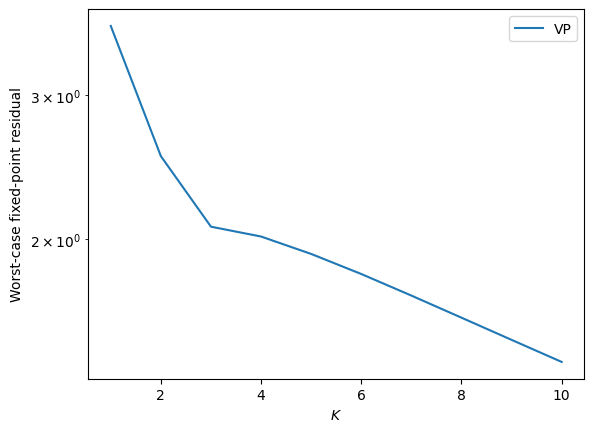

In [23]:
plt.plot(range(1, K+1), all_residuals, label='VP')
plt.yscale('log')
plt.ylabel('Worst-case fixed-point residual')
plt.xlabel(r'$K$')
plt.legend()